## 분류와 군집화

### 로지스틱 회귀 모델과 시그모이드 함수

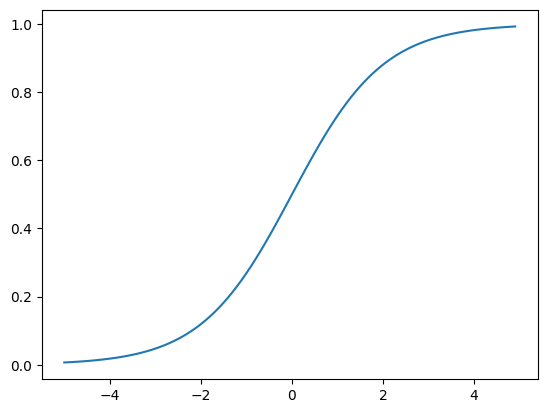

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(x):
   return 1.0/(1.0 + np.exp(-x))

x = np.arange(-5., 5., 0.1)
plt.plot(x, sigmoid(x))

**시그모이드 함수와 지수의 관계**

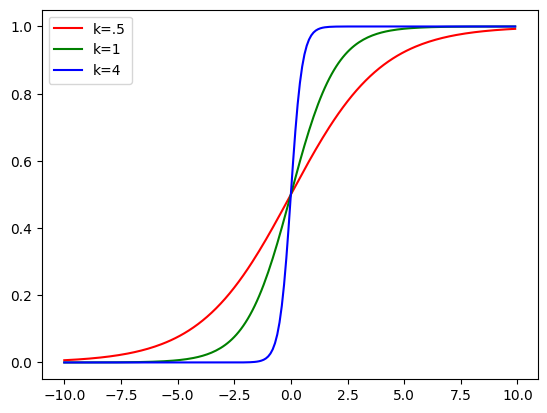

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(x, k):
   return 1.0/(1.0 + np.exp(-x*k))

x = np.arange(-10., 10., 0.1)
plt.plot(x, sigmoid(x, .5), 'r', label='k=.5')
plt.plot(x, sigmoid(x, 1), 'g', label='k=1')
plt.plot(x, sigmoid(x, 4), 'b', label='k=4')
plt.legend()

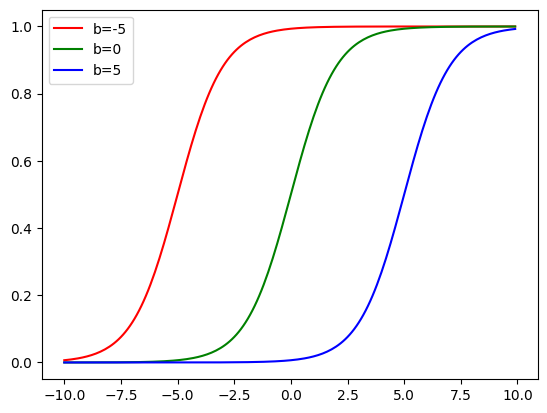

In [3]:
def sigmoid(x, b):
  return 1.0/(1.0 + np.exp(-x + b))

x = np.arange(-10., 10., 0.1)
plt.plot(x, sigmoid(x, b=-5), 'r', label='b=-5')
plt.plot(x, sigmoid(x, b=0), 'g', label='b=0')
plt.plot(x, sigmoid(x, b=5), 'b', label='b=5')
plt.legend()

## 결정 경계와 교차 엔트로피(비용함수)

### 로지스틱 회귀 모델을 위한 데이터 만들기

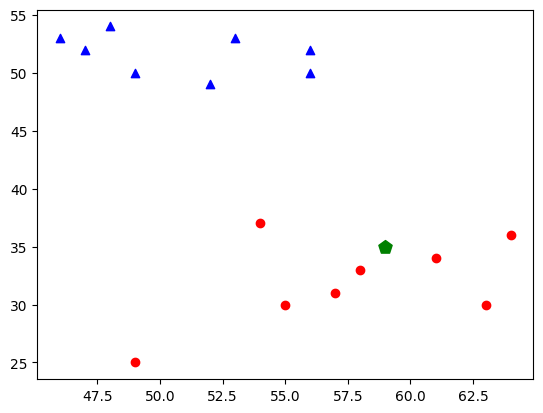

In [6]:
import matplotlib.pyplot as plt

# 닥스훈트의 길이와 높이 데이터
dach_length = [55, 57, 64, 63, 58, 49, 54, 61]
dach_height = [30, 31, 36, 30, 33, 25, 37, 34]
# 진돗개의 길이와 높이 데이터
jin_length = [56, 47, 56, 46, 49, 53, 52, 48]
jin_height = [52, 52, 50, 53, 50, 53, 49, 54]

#모르는 데이타. 테스트 데이타
newdata_length = [59]    # 새로운 데이터의 길이
newdata_height = [35]    # 새로운 데이터의 높이

plt.scatter(dach_length, dach_height, c='r', label='Dachshund')
plt.scatter(jin_length, jin_height,c='b',marker='^', label='Jindo dog')
# 새 데이터의 표식은 오각형(pentagon)으로 설정하고, 레이블은 new Data로
plt.scatter(newdata_length, newdata_height, s=100, marker='p', c='g', label='new Data')

#plt.xlabel('Length')
#plt.ylabel('Height')
#plt.title("Dog size")
#plt.legend(loc='upper right')

**데이타 생성 단계1**

In [9]:
import numpy as np

d_data = np.column_stack((dach_length, dach_height))
d_label = np.zeros(len(d_data))   # 닥스훈트는 0으로 레이블링

j_data = np.column_stack((jin_length, jin_height))
j_label = np.ones(len(j_data))   # 진돗개는 1로 레이블링

print(d_data), print(d_label)

[[55 30]
 [57 31]
 [64 36]
 [63 30]
 [58 33]
 [49 25]
 [54 37]
 [61 34]]
[0. 0. 0. 0. 0. 0. 0. 0.]


(None, None)

**데이타 생성 단계2**

In [ ]:
dogs = np.concatenate((d_data, j_data))
labels = np.concatenate((d_label, j_label))
print(dogs, labels)
dog_classes = {0:'닥스훈트', 1:'진돗개'}
newdata = [[59, 35]] #unknown dog


[[55 30]
 [57 31]
 [64 36]
 [63 30]
 [58 33]
 [49 25]
 [54 37]
 [61 34]
 [56 52]
 [47 52]
 [56 50]
 [46 53]
 [49 50]
 [53 53]
 [52 49]
 [48 54]] [0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 1. 1. 1. 1.]


**회귀 모델 구현**

In [ ]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn import metrics

f = LogisticRegression() #분류
f.fit(dogs, labels)
w = f.coef_[0] # 계수. 이건 형태를 파악 후 구해야 할 것 같다.
b = f.intercept_[0] # 절편. 이것도 형태를 파악 후 구해야 할 것 같다.
print('계수:', w)
print('절편:', b)
print('분류 정확도:', f.score(dogs, labels))

y_pred = f.predict(newdata) #predict 함수는 배열 형태로 리턴
y_pred_prob = f.predict_proba(newdata) #predict_proba 함수는 배열 형태로 리턴
print(f'데이터: {newdata}')
print(f'판정 결과: {dog_classes[y_pred[0]]}, 판정 확률: {y_pred_prob}')

계수: [-0.12467735  0.60518946]
절편: -19.029836138332463
분류 정확도: 1.0
데이터: [[59, 35]]
판정 결과: 닥스훈트, 판정 확률: [[0.9945364 0.0054636]]


**결정 경계에서 w0*x0 + w1*x1 + b = 0 이므로 => x1 = -w0/w1 * x0 - b/w1**


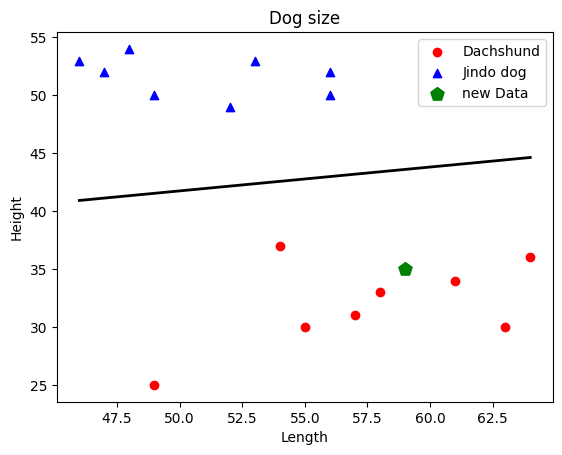

In [12]:
plt.scatter(dach_length, dach_height, c='r', label='Dachshund')
plt.scatter(jin_length, jin_height,c='b',marker='^', label='Jindo dog')
# 새 데이터의 표식은 오각형(pentagon)으로 설정하고, 레이블은 new Data로
plt.scatter(newdata_length, newdata_height, s=100, marker='p', c='g', label='new Data')

plt.xlabel('Length')
plt.ylabel('Height')
plt.title("Dog size")
plt.legend(loc='upper right')

x0 = np.linspace(np.min([dach_length, jin_length]),\
                 np.max([dach_length, jin_length]), 200)
decision_boundary = -w[0]/w[1] * x0 - b/w[1]
# 결정 경계에서 w0*x0 + w1*x1 + b = 0 이므로 => x1 = -w0/w1 * x0 - b/w1
plt.plot(x0, decision_boundary, "k-", linewidth=2)
plt.show()